In [1]:
# Cell 1: imports & global config

import os
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import networkx as nx
from pyvis.network import Network
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 建议：在 Jupyter 里画图
# %matplotlib inline

# 随机种子（主要用于可复现实验，比如 TSNE）
RANDOM_SEED = 2025
np.random.seed(RANDOM_SEED)


In [2]:
# Cell 2: load DistMult triples for PPMI (PD / Control / Prodromal / SWEDD)

# DistMult 训练脚本中的前缀
PREFIX = "distmult_PD"

TRIPLE_ALL   = f"triples_{PREFIX}.tsv"   # 推荐优先使用
TRIPLE_TRAIN = f"train_{PREFIX}.tsv"
TRIPLE_VALID = f"valid_{PREFIX}.tsv"
TRIPLE_TEST  = f"test_{PREFIX}.tsv"

def load_triples():
    paths = []
    if os.path.exists(TRIPLE_ALL):
        paths = [TRIPLE_ALL]
    else:
        # 如果没有总表，就把 train/valid/test 拼一起
        for p in [TRIPLE_TRAIN, TRIPLE_VALID, TRIPLE_TEST]:
            if os.path.exists(p):
                paths.append(p)
    if not paths:
        raise FileNotFoundError(
            "没有找到 triples_distmult_PD.tsv 或 train/valid/test_distmult_PD.tsv，"
            "请确认与训练脚本在同一目录运行。"
        )
    
    dfs = []
    for p in paths:
        df = pd.read_csv(p, sep="\t", header=None, names=["h", "r", "t"])
        dfs.append(df)
        print(f"Loaded {p}: {len(df):,} triples")
    
    triples = pd.concat(dfs, ignore_index=True).drop_duplicates()
    print(f"==> Total unique triples: {len(triples):,}")
    return triples

triples = load_triples()
triples.head()


Loaded triples_distmult_PD.tsv: 46,093 triples
==> Total unique triples: 26,653


,h,r,t
0,57037,belongs_to_group,PD
1,57037,has_sex,F
2,57037,has_age_bin,age_50_59
3,57037,visit_phase,BL
4,57037,has_Type,Processed


In [3]:
# Cell 3: collect subject IDs from CSVs & build diagnostic KG graph

# 如果 swedd.csv 不在目录里，下面会自动跳过，不报错
CSV_FILES = {
    "PD":        "PD1.csv",
    "Control":   "control.csv",
    "Prodromal": "prodromal.csv",
    "SWEDD":     "swedd.csv",
}

SUBJECT_IDS = set()
for group, path in CSV_FILES.items():
    if os.path.exists(path):
        df_tmp = pd.read_csv(path)
        if "Subject" in df_tmp.columns:
            SUBJECT_IDS.update(df_tmp["Subject"].astype(str).tolist())
            print(f"[{group}] loaded {path}, subjects: {df_tmp['Subject'].nunique()}")
        else:
            print(f"[WARN] {path} 没有 'Subject' 列，跳过 subject 收集。")
    else:
        print(f"[INFO] {path} 不存在，跳过。")

print(f"Total unique Subject IDs collected: {len(SUBJECT_IDS)}")

# 一些已知的“特殊实体”
GROUPS = {"PD", "Control", "Prodromal", "SWEDD"}
VISITS = {"BL", "V04", "V06", "V08", "V10"}
SEX_VALUES = {"M", "F", "Male", "Female", "male", "female"}
YES_NO = {"Yes", "No"}
STAGES = {"Stage_0", "Stage_1", "Stage_2", "Stage_3", "Stage_4"}

def classify_entity(e: str) -> str:
    """
    给实体一个粗糙类型（etype），用于可视化配色。
    e 一定转成字符串再处理。
    """
    e = str(e)
    if e in GROUPS:
        return "group"
    if e in VISITS:
        return "visit"
    if e in SEX_VALUES:
        return "sex"
    if e in STAGES:
        return "stage"
    if e.startswith("age_"):
        return "age_bin"
    if e in YES_NO:
        return "yesno"
    
    # 如果是 Subject ID（在 CSV 中真实出现过的），优先认定为 subject
    if e in SUBJECT_IDS:
        return "subject"
    
    # 纯数字再细分：长数字当作 Subject / ID，短数字当作取值
    if e.isdigit():
        if len(e) >= 5:
            return "subject"
        else:
            return "value"
    
    # 带小数点的数字
    try:
        float(e)
        return "value"
    except ValueError:
        pass
    
    # 默认归为 feature（症状条目 / 量表条目 / meta）
    return "feature"

# === 构建 MultiDiGraph ===
G = nx.MultiDiGraph()

for row in triples.itertuples(index=False):
    h, r, t = str(row.h), str(row.r), str(row.t)
    if not h or not t:
        continue
    et_h = classify_entity(h)
    et_t = classify_entity(t)
    G.add_node(h, label=h, etype=et_h)
    G.add_node(t, label=t, etype=et_t)
    G.add_edge(h, t, relation=r)

print(f"Graph built: |V|={G.number_of_nodes():,}, |E|={G.number_of_edges():,}")


[PD] loaded PD1.csv, subjects: 184
[Control] loaded control.csv, subjects: 74
[Prodromal] loaded prodromal.csv, subjects: 44
[SWEDD] loaded swedd.csv, subjects: 37
Total unique Subject IDs collected: 339
Graph built: |V|=438, |E|=26,653


Selected PD subject_id: 57037
Ego graph nodes: 17, edges: 54


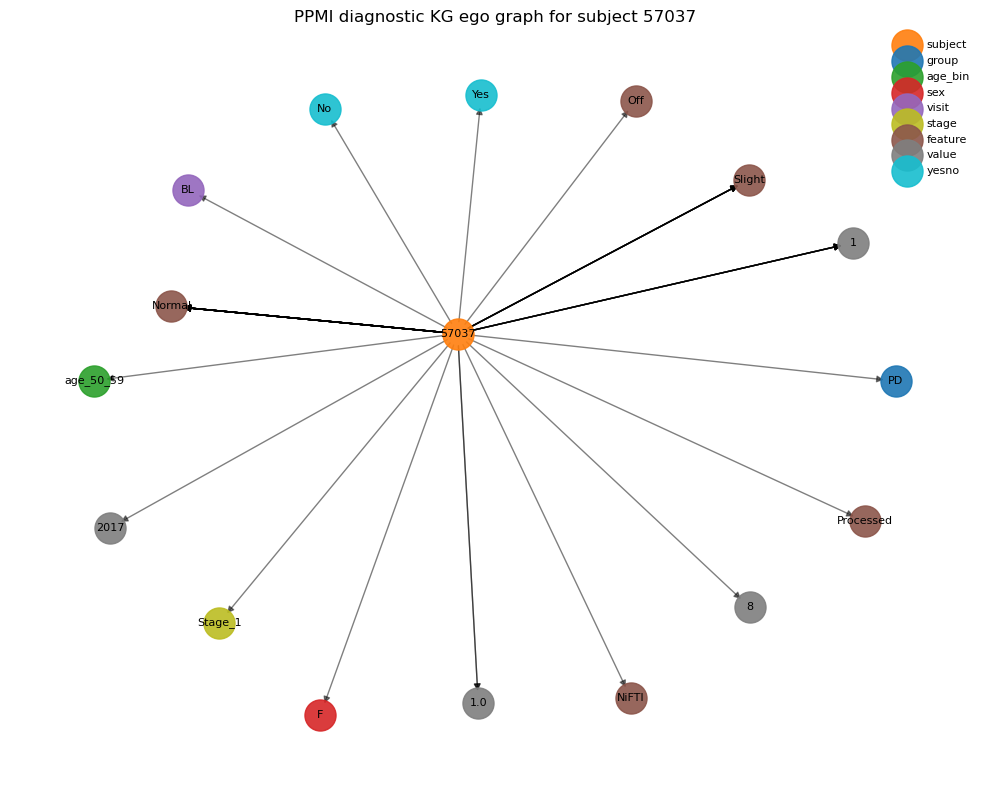

Ego graph saved to: ppmi_patient_ego.png


In [5]:
# Cell 4 (替换版): visualize ego graph for a single PD subject (matplotlib)

# 1) 从 PD1.csv 中选一个 Subject
pd_path = CSV_FILES["PD"]
if not os.path.exists(pd_path):
    raise FileNotFoundError(f"{pd_path} 不存在，请确认路径。")

pd_df = pd.read_csv(pd_path)
if "Subject" not in pd_df.columns:
    raise KeyError(f"{pd_path} 中没有 'Subject' 列。")

# 随便选一个 PD Subject（你也可以手动写一个）
subject_id = str(pd_df["Subject"].iloc[0])
print("Selected PD subject_id:", subject_id)

if subject_id not in G:
    print(f"[WARN] 在知识图谱中找不到节点 {subject_id}，"
          f"可能三元组里用的是其他 ID（例如 Image Data ID）。")
    print("你可以在这里手动改成 G 中存在的某个节点 ID 再试。")

# 2) 以该 subject 为中心取一跳 ego graph
radius = 1  # 想更丰富可以设为 2
ego = nx.ego_graph(G, subject_id, radius=radius, center=True)

print(f"Ego graph nodes: {ego.number_of_nodes()}, edges: {ego.number_of_edges()}")

# 3) 用 matplotlib 可视化
plt.figure(figsize=(10, 8))

# 用 spring layout 布局
pos = nx.spring_layout(ego, seed=RANDOM_SEED)

color_map = {
    "subject": "#ff7f0e",
    "group":   "#1f77b4",
    "age_bin": "#2ca02c",
    "sex":     "#d62728",
    "visit":   "#9467bd",
    "stage":   "#bcbd22",
    "feature": "#8c564b",
    "value":   "#7f7f7f",
    "yesno":   "#17becf",
}

# 按 etype 分组画节点
for etype, c in color_map.items():
    nodes = [n for n, d in ego.nodes(data=True) if d.get("etype") == etype]
    if not nodes:
        continue
    nx.draw_networkx_nodes(
        ego, pos, nodelist=nodes,
        node_color=c, label=etype, node_size=500, alpha=0.9
    )

# 画边
nx.draw_networkx_edges(
    ego, pos, arrowstyle='-|>', arrows=True, alpha=0.5
)

# 标签：用 node 的 label 字段
labels = {n: d.get("label", str(n)) for n, d in ego.nodes(data=True)}
nx.draw_networkx_labels(ego, pos, labels=labels, font_size=8)

plt.title(f"PPMI diagnostic KG ego graph for subject {subject_id}")
plt.axis("off")
plt.legend(scatterpoints=1, fontsize=8, loc="best", frameon=False)
plt.tight_layout()

out_png = "ppmi_patient_ego.png"
plt.savefig(out_png, dpi=300)
plt.show()
print(f"Ego graph saved to: {out_png}")



subject2group size: 339
PD: 345 distinct features
Control: 127 distinct features
Prodromal: 192 distinct features
SWEDD: 224 distinct features
Total selected features (union over groups): 26
H graph: |V|=30, |E|=103


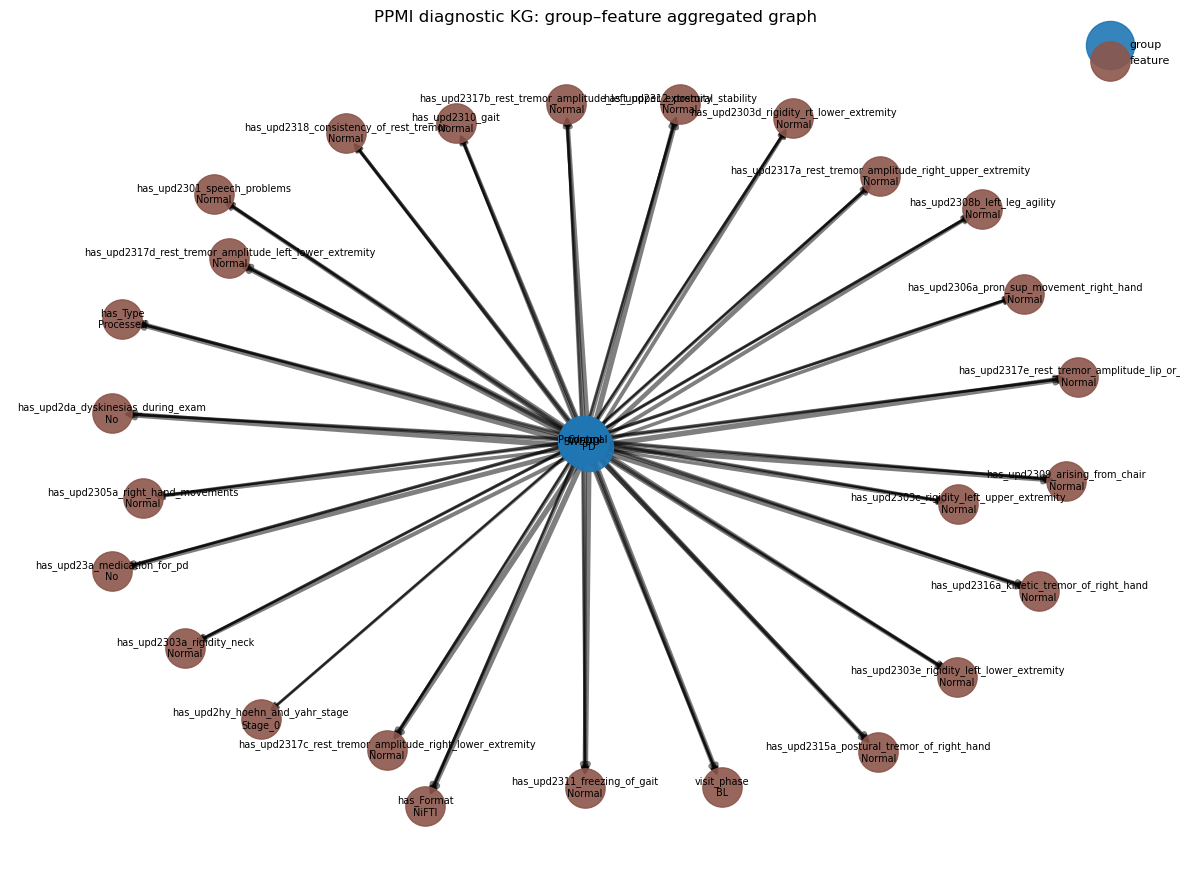

Group-feature graph saved to: ppmi_group_feature_graph.png


In [6]:
# Cell 5 (替换版): aggregated group -> feature diagnostic KG (matplotlib)

# 1) 从三元组中提取 subject -> group 映射
subject2group = {}

for row in triples.itertuples(index=False):
    h, r, t = str(row.h), str(row.r), str(row.t)
    if r == "belongs_to_group":
        subject2group[h] = t

print(f"subject2group size: {len(subject2group)}")

# 2) 统计每个 group 与特征 (r, t) 的共现次数
group_feature_counter = defaultdict(Counter)

for row in triples.itertuples(index=False):
    h, r, t = str(row.h), str(row.r), str(row.t)
    if r == "belongs_to_group":
        continue
    group = subject2group.get(h, None)
    if group is None:
        continue
    feature = (r, t)   # 用 (关系, tail 值) 唯一标识一个特征
    group_feature_counter[group][feature] += 1

for g, counter in group_feature_counter.items():
    print(f"{g}: {len(counter)} distinct features")

# 3) 选每个 group 中 top-K 最常见的特征
K = 12
selected_features = set()
for g, counter in group_feature_counter.items():
    for ft, cnt in counter.most_common(K):
        selected_features.add(ft)

print(f"Total selected features (union over groups): {len(selected_features)}")

# 4) 构建聚合图 H: group -> feature
H = nx.DiGraph()

# 添加 group 节点
for g in GROUPS:
    if g in group_feature_counter:  # 只加确实出现过的
        H.add_node(g, etype="group", label=g)

# 添加 feature 节点 + 边
for (r, t) in selected_features:
    node_id = f"{r}::{t}"
    label   = f"{r}\n{t}"
    H.add_node(node_id, etype="feature", label=label)
    for g, counter in group_feature_counter.items():
        w = counter.get((r, t), 0)
        if w > 0:
            H.add_edge(g, node_id, weight=w)

print(f"H graph: |V|={H.number_of_nodes()}, |E|={H.number_of_edges()}")

# 5) 用 matplotlib 画聚合图
plt.figure(figsize=(12, 9))

pos = nx.spring_layout(H, seed=RANDOM_SEED, k=0.6)

# group 节点 & feature 节点分开上色
group_nodes = [n for n, d in H.nodes(data=True) if d.get("etype") == "group"]
feat_nodes  = [n for n, d in H.nodes(data=True) if d.get("etype") == "feature"]

nx.draw_networkx_nodes(
    H, pos, nodelist=group_nodes,
    node_color="#1f77b4", node_size=1200, alpha=0.9, label="group"
)
nx.draw_networkx_nodes(
    H, pos, nodelist=feat_nodes,
    node_color="#8c564b", node_size=800, alpha=0.9, label="feature"
)

# 边宽度按权重
weights = [H[u][v]["weight"] for u, v in H.edges()]
max_w = max(weights) if weights else 1
edge_widths = [1 + 3 * (w / max_w) for w in weights]

nx.draw_networkx_edges(
    H, pos, width=edge_widths, alpha=0.5, arrows=True, arrowstyle='-|>'
)

# 标签
labels = {n: d.get("label", str(n)) for n, d in H.nodes(data=True)}
nx.draw_networkx_labels(H, pos, labels=labels, font_size=7)

plt.title("PPMI diagnostic KG: group–feature aggregated graph")
plt.axis("off")
plt.legend(scatterpoints=1, fontsize=8, loc="best", frameon=False)
plt.tight_layout()

out_png2 = "ppmi_group_feature_graph.png"
plt.savefig(out_png2, dpi=300)
plt.show()
print(f"Group-feature graph saved to: {out_png2}")


Number of entities in id2ent: 438
Embedding shape: (438, 32)


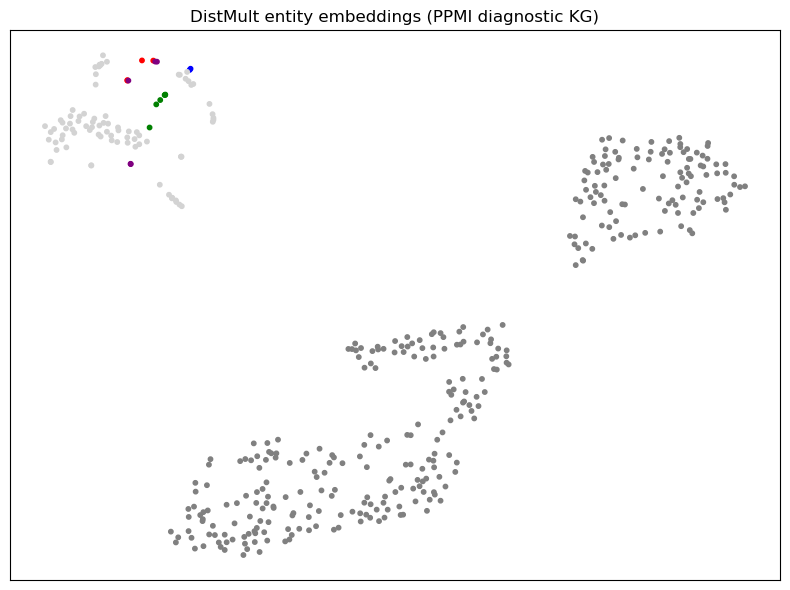

In [7]:
# Cell 6: TSNE visualization of DistMult entity embeddings

ENTITY2ID_PATH = f"entity2id_{PREFIX}.txt"
EMB_PATH       = f"entity_embeddings_{PREFIX}.npy"

if not os.path.exists(ENTITY2ID_PATH):
    raise FileNotFoundError(f"{ENTITY2ID_PATH} 不存在，请确认与训练脚本在同一目录。")
if not os.path.exists(EMB_PATH):
    raise FileNotFoundError(f"{EMB_PATH} 不存在，请确认已保存 DistMult 嵌入。")

# 1) 读入实体字典
id2ent = {}
with open(ENTITY2ID_PATH, "r", encoding="utf-8") as f:
    for line in f:
        ent, idx = line.strip().split("\t")
        id2ent[int(idx)] = ent

print("Number of entities in id2ent:", len(id2ent))

# 2) 读入实体嵌入
emb = np.load(EMB_PATH)  # [num_entities, dim]
print("Embedding shape:", emb.shape)

if emb.shape[0] != len(id2ent):
    print("[WARN] 嵌入数量与 entity2id 行数不一致，请检查。")

# 3) TSNE 降维到 2D
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_SEED,
    init="random",
    learning_rate="auto",
)
X_2d = tsne.fit_transform(emb)

# 4) 按 etype 上色
colors = []
for idx in range(emb.shape[0]):
    e = id2ent.get(idx, str(idx))
    et = classify_entity(e)
    if et == "group":
        c = "red"
    elif et == "subject":
        c = "gray"
    elif et == "age_bin":
        c = "green"
    elif et == "sex":
        c = "blue"
    elif et == "stage":
        c = "purple"
    else:
        c = "lightgray"
    colors.append(c)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=10, c=colors)
plt.title("DistMult entity embeddings (PPMI diagnostic KG)")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()


In [8]:
# Cell 7: build a small textual KG about PD & UPDRS for visualization

# 这里手工构造一批 (head, relation, tail) 三元组
text_triples_list = [
    ("Parkinson's disease", "is_a", "Neurodegenerative disorder"),
    ("Parkinson's disease", "characterized_by", "Motor symptoms"),
    ("Parkinson's disease", "characterized_by", "Non-motor symptoms"),
    
    ("Motor symptoms", "include", "Bradykinesia"),
    ("Motor symptoms", "include", "Rigidity"),
    ("Motor symptoms", "include", "Rest tremor"),
    ("Motor symptoms", "include", "Postural instability"),
    
    ("Bradykinesia", "assessed_by", "Body bradykinesia (UPDRS-2314)"),
    ("Rigidity", "assessed_by", "Neck rigidity (UPDRS-2303a)"),
    ("Gait disturbance", "assessed_by", "Gait (UPDRS-2310)"),
    ("Postural instability", "assessed_by", "Postural stability (UPDRS-2312)"),
    ("Rest tremor", "assessed_by", "Rest tremor amplitude (UPDRS-2317)"),
    
    ("Non-motor symptoms", "include", "Sleep problems"),
    ("Non-motor symptoms", "include", "Mood disturbance"),
    ("Non-motor symptoms", "include", "Cognitive impairment"),
    
    ("Levodopa", "treats", "Motor symptoms"),
    ("Dopamine agonists", "treat", "Motor symptoms"),
    ("Deep brain stimulation", "treats", "Motor complications"),
]

text_triples = pd.DataFrame(text_triples_list, columns=["h", "r", "t"])
text_triples.head()


,h,r,t
0,Parkinson's disease,is_a,Neurodegenerative disorder
1,Parkinson's disease,characterized_by,Motor symptoms
2,Parkinson's disease,characterized_by,Non-motor symptoms
3,Motor symptoms,include,Bradykinesia
4,Motor symptoms,include,Rigidity


In [9]:
# Cell 8: classify entities in textual KG and build graph

def classify_text_entity(e: str) -> str:
    e_low = e.lower()
    if "parkinson" in e_low:
        return "disease"
    if "symptom" in e_low:
        return "symptom_group"
    if any(k in e_low for k in ["bradykinesia", "rigidity", "tremor", "gait", "postural", "instability"]):
        return "motor_symptom"
    if any(k in e_low for k in ["sleep", "mood", "cognitive"]):
        return "nonmotor_symptom"
    if any(k in e_low for k in ["updrs", "hoehn", "scale"]):
        return "scale_item"
    if any(k in e_low for k in ["levodopa", "agonist", "stimulation"]):
        return "treatment"
    if "neurodegenerative" in e_low:
        return "disease_category"
    return "other"

G_text = nx.DiGraph()

for row in text_triples.itertuples(index=False):
    h, r, t = row.h, row.r, row.t
    G_text.add_node(h, label=h, etype=classify_text_entity(h))
    G_text.add_node(t, label=t, etype=classify_text_entity(t))
    G_text.add_edge(h, t, relation=r)

print(f"Text KG: |V|={G_text.number_of_nodes()}, |E|={G_text.number_of_edges()}")


Text KG: |V|=21, |E|=18


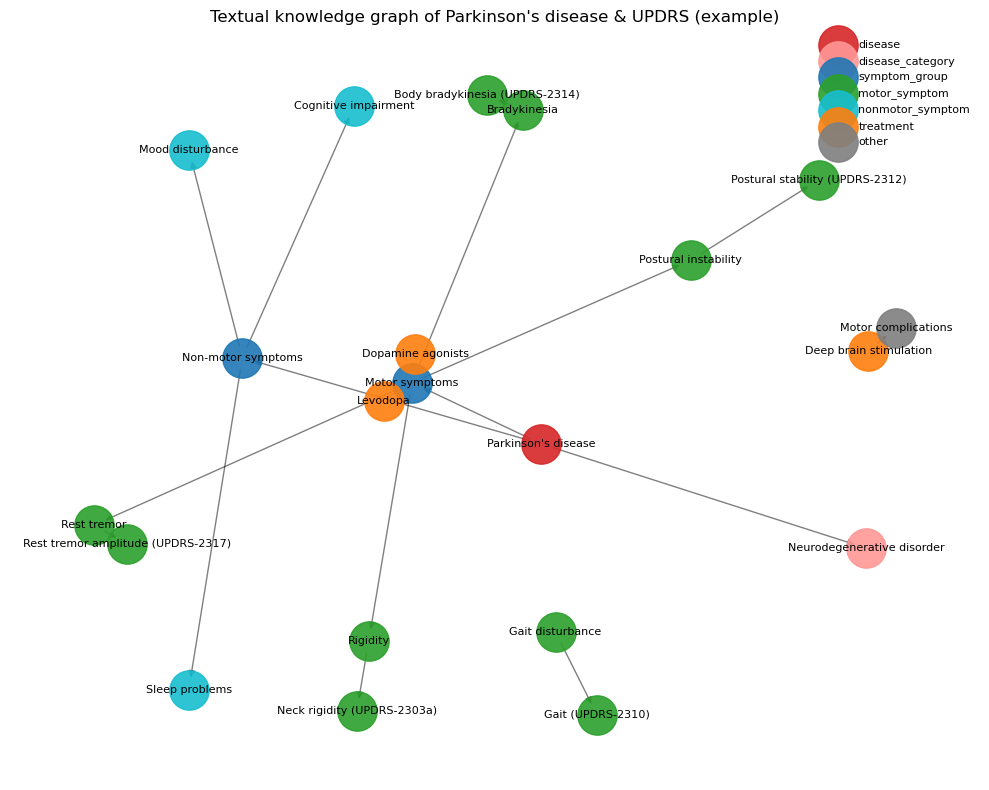

Textual KG saved to: ppmi_textual_kg.png


In [10]:
# Cell 9 (替换版): visualize textual KG with matplotlib

plt.figure(figsize=(10, 8))

pos_text = nx.spring_layout(G_text, seed=RANDOM_SEED)

text_color_map = {
    "disease":          "#d62728",
    "disease_category": "#ff9896",
    "symptom_group":    "#1f77b4",
    "motor_symptom":    "#2ca02c",
    "nonmotor_symptom": "#17becf",
    "scale_item":       "#9467bd",
    "treatment":        "#ff7f0e",
    "other":            "#7f7f7f",
}

# 分类型画节点
for etype, c in text_color_map.items():
    nodes = [n for n, d in G_text.nodes(data=True) if d.get("etype") == etype]
    if not nodes:
        continue
    nx.draw_networkx_nodes(
        G_text, pos_text, nodelist=nodes,
        node_color=c, node_size=800, alpha=0.9, label=etype
    )

# 边
nx.draw_networkx_edges(
    G_text, pos_text, arrowstyle='-|>', arrows=True, alpha=0.5
)

# 标签
labels_text = {n: d.get("label", str(n)) for n, d in G_text.nodes(data=True)}
nx.draw_networkx_labels(G_text, pos_text, labels=labels_text, font_size=8)

plt.title("Textual knowledge graph of Parkinson's disease & UPDRS (example)")
plt.axis("off")
plt.legend(scatterpoints=1, fontsize=8, loc="best", frameon=False)
plt.tight_layout()

out_png_text = "ppmi_textual_kg.png"
plt.savefig(out_png_text, dpi=300)
plt.show()
print(f"Textual KG saved to: {out_png_text}")
